In [17]:
!pip install transformers

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import f1_score
import numpy as np
import os
from PIL import Image
from tqdm import tqdm
from torch import nn
import torch
from torch.nn import TransformerEncoder, TransformerEncoderLayer


In [2]:

torch.cuda.empty_cache()
print(f"GPU Memory Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU Memory Cached: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

GPU Memory Allocated: 0.00 GB
GPU Memory Cached: 0.00 GB


In [1]:
import os
import torch
from PIL import Image
from tqdm import tqdm
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import f1_score
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 40
NUM_CLASSES = 3
TRAIN_DIR = "../split_data/train"
TEST_DIR = "../split_data/test"
GRAD_ACCUMULATION_STEPS = 4  # Number of batches to accumulate gradients over
EFFECTIVE_BATCH_SIZE = BATCH_SIZE * GRAD_ACCUMULATION_STEPS  # This is your effective batch size

# === Data Preparation ===
def get_transforms(train=True):
    if train:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomRotation(20),
            transforms.RandomHorizontalFlip(),
            transforms.RandomAffine(0, shear=20, scale=(0.8, 1.2)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

class ChestXrayDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.images = self._load_images()

    def _load_images(self):
        return [
            (os.path.join(cls_dir, img), self.class_to_idx[cls])
            for cls in self.classes
            for cls_dir, _, files in os.walk(os.path.join(self.root_dir, cls))
            for img in files
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path, label = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

def get_dataloaders():
    train_ds = ChestXrayDataset(TRAIN_DIR, get_transforms(train=True))
    val_ds = ChestXrayDataset(TEST_DIR, get_transforms(train=False))
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, val_loader

# === Model ===
class TransformerHead(nn.Module):
    def __init__(self, input_dim=2048, hidden_dim=256, num_classes=3, nhead=8, num_layers=2):
        super().__init__()
        self.projection = nn.Linear(input_dim, hidden_dim)
        encoder_layer = TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            dim_feedforward=hidden_dim*4,
            dropout=0.1,
            activation='gelu'
        )
        self.transformer = TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.projection(x).unsqueeze(1)  # (B, 1, H)
        x = x.permute(1, 0, 2)               # (1, B, H)
        x = self.transformer(x)
        x = x.mean(dim=0)                   # (B, H)
        return self.classifier(x)

class CNNTransformerModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base_model = models.resnet50(weights='IMAGENET1K_V2')
        self.cnn = nn.Sequential(*list(base_model.children())[:-1])  # Remove FC
        self.head = TransformerHead(input_dim=2048, hidden_dim=256, num_classes=num_classes)

    def forward(self, x):
        x = self.cnn(x).squeeze()  # (B, 2048, 1, 1) → (B, 2048)
        return self.head(x)

# === Training with Gradient Accumulation ===
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    # Initialize gradient accumulation step counter
    step = 0
    optimizer.zero_grad()  # Zero gradients at the beginning of the epoch
    
    for inputs, labels in tqdm(loader, desc="Training"):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels) / GRAD_ACCUMULATION_STEPS  # Scale loss
        
        # Backward pass
        loss.backward()
        
        # Accumulate batch statistics
        running_loss += loss.item() * GRAD_ACCUMULATION_STEPS  # Adjust loss for reporting
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        step += 1
        
        # Update weights after accumulating gradients for specified number of steps
        if step % GRAD_ACCUMULATION_STEPS == 0:
            optimizer.step()
            optimizer.zero_grad()
    
    # Handle any remaining gradients if dataset size is not divisible by effective batch size
    if step % GRAD_ACCUMULATION_STEPS != 0:
        optimizer.step()
        optimizer.zero_grad()

    acc = correct / total
    f1 = f1_score(all_labels, all_preds, average='macro')
    return running_loss / len(loader), acc, f1

def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Validation"):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    f1 = f1_score(all_labels, all_preds, average='macro')
    return running_loss / len(loader), acc, f1

# === Full Training Loop ===
def train_model():
    train_loader, val_loader = get_dataloaders()
    model = CNNTransformerModel(num_classes=NUM_CLASSES).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=2)
    best_f1 = 0.0
    history = {'train_loss': [], 'train_acc': [], 'train_f1': [],
               'val_loss': [], 'val_acc': [], 'val_f1': []}

    print(f"Training with effective batch size: {EFFECTIVE_BATCH_SIZE} (batch_size={BATCH_SIZE}, grad_accum_steps={GRAD_ACCUMULATION_STEPS})")
    
    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        tr_loss, tr_acc, tr_f1 = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['train_f1'].append(tr_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        scheduler.step(val_f1)

        print(f"Train Loss: {tr_loss:.4f} | Acc: {tr_acc:.4f} | F1: {tr_f1:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_model_resnet50_gradaccum.pth")
            print(f"Saved best model with F1: {best_f1:.4f}")

    # Final evaluation
    print("\n=== Final Evaluation ===")
    print(f"Best Validation F1: {best_f1:.4f}")
    return model, history



In [2]:
if __name__ == "__main__":
    model,history=train_model()

D:\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Training with effective batch size: 128 (batch_size=32, grad_accum_steps=4)

Epoch 1/40


Validation: 100%|██████████████████████████████████████████████████████████████████████| 43/43 [00:32<00:00,  1.30it/s]


Train Loss: 0.5386 | Acc: 0.8224 | F1: 0.8231
Val Loss: 0.2993 | Acc: 0.9142 | F1: 0.9160
Saved best model with F1: 0.9160

Epoch 2/40


Validation: 100%|██████████████████████████████████████████████████████████████████████| 43/43 [00:33<00:00,  1.30it/s]


...

Train Loss: 0.0742 | Acc: 0.9738 | F1: 0.9740
Val Loss: 0.1461 | Acc: 0.9535 | F1: 0.9539

Epoch 39/40


Validation: 100%|██████████████████████████████████████████████████████████████████████| 43/43 [00:31<00:00,  1.36it/s]


Train Loss: 0.0752 | Acc: 0.9731 | F1: 0.9733
Val Loss: 0.1455 | Acc: 0.9564 | F1: 0.9568

Epoch 40/40


Validation: 100%|██████████████████████████████████████████████████████████████████████| 43/43 [00:31<00:00,  1.38it/s]

Train Loss: 0.0763 | Acc: 0.9727 | F1: 0.9730
Val Loss: 0.1461 | Acc: 0.9578 | F1: 0.9583

=== Final Evaluation ===
Best Validation F1: 0.9619


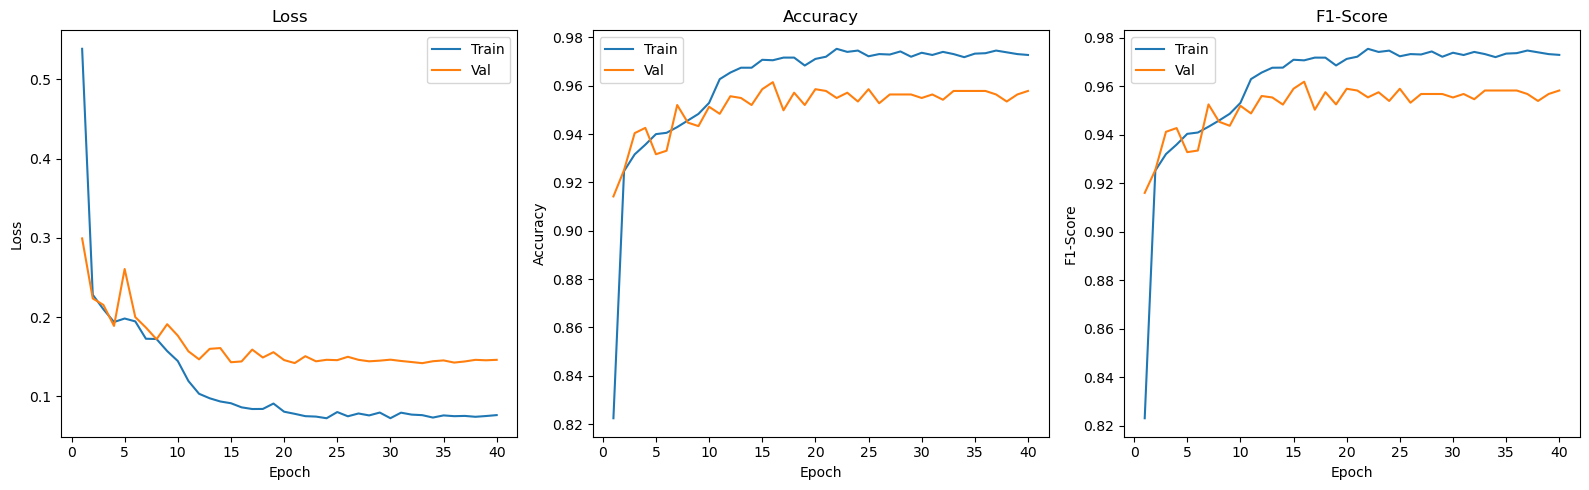

In [4]:
plot_metrics(history)